# EDA - Census Dataset

**Objetivo:** Explorar, limpiar y preparar el dataset `Census.csv` para modelado predictivo del nivel de ingresos (Alto/Bajo/Medio).

**Dataset original:** Census Income dataset (Adult) - 32,561 registros, 12 variables.

**Flujo del notebook:**
1. Configuración del entorno
2. Carga de datos
3. Renombrado de variables (V1-V12 → nombres descriptivos)
4. Estructura y limpieza de datos
5. Análisis de valores perdidos
6. **Comparación de imputaciones**: Mediana vs KNN
7. Detección y eliminación de duplicados
8. Visualización de datos
9. Exportación del dataset limpio

In [1]:
# ===========================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ===========================================================
# Ejecutar solo una vez al inicio.
# Si falta algún paquete, instalar con:
# conda install pandas numpy seaborn matplotlib scikit-learn missingno
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import KNNImputer, SimpleImputer
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga de Datos

Cargamos el archivo `Census.csv` usando `pathlib` para manejar rutas de forma portable.

**El dataset contiene:** Información demográfica y laboral de 32,561 personas.
**Variable objetivo (target):** `nivel_ingresos` - Alto, Bajo, Medio.

In [2]:
# ===========================================================
# 2. CARGA DE DATOS
# ===========================================================

# Intentar carga con path relativo al notebook
try:
    ruta = Path(__file__).parent / 'Census.csv'
    censo = pd.read_csv(ruta, encoding='latin-1')
except NameError:
    # Fallback: misma carpeta
    censo = pd.read_csv('Census.csv', encoding='latin-1')

print(f'Dataset cargado: {censo.shape[0]} filas, {censo.shape[1]} columnas')

Dataset cargado: 32561 filas, 12 columnas


In [3]:
# Vista previa de los datos
censo.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12
0,58,Dependiente,147653,Primaria,Soltero,Medio,Media,Femenino,0.0,1977,35,Alto
1,39,Dependiente,108140,Superior,Soltero,Alto,Alta,Masculino,0.0,0,50,Alto
2,49,Dependiente,188823,Secundaria,Soltero,Alto,Alta,Masculino,0.0,0,42,Alto
3,39,Dependiente,249720,Técnico,Soltero,Alto,Baja,Femenino,0.0,0,60,Bajo
4,18,Dependiente,181712,Secundaria,Conviviente,Alto,Alta,Masculino,0.0,0,12,Alto


---
## 3. Renombrado de Variables

Las columnas originales tienen nombres genéricos (`V1`, `V2`, ..., `V12`).
Las renombramos con nombres descriptivos para mejorar la legibilidad del análisis.

In [4]:
# ===========================================================
# 3. RENOMBRADO DE VARIABLES
# ===========================================================

MAPEO_COLUMNAS = {
    'V1': 'edad',
    'V2': 'tipo_relacion_laboral',
    'V3': 'impuestos_anuales',
    'V4': 'nivel_educativo',
    'V5': 'estado_civil',
    'V6': 'clase_trabajo',
    'V7': 'educacion_final',
    'V8': 'genero',
    'V9': 'ganancia_capital',
    'V10': 'perdida_capital',
    'V11': 'horas_semanales',
    'V12': 'nivel_ingresos'
}

censo.rename(columns=MAPEO_COLUMNAS, inplace=True)
print('Variables renombradas correctamente.')
print(f'Columnas: {list(censo.columns)}')

Variables renombradas correctamente.
Columnas: ['edad', 'tipo_relacion_laboral', 'impuestos_anuales', 'nivel_educativo', 'estado_civil', 'clase_trabajo', 'educacion_final', 'genero', 'ganancia_capital', 'perdida_capital', 'horas_semanales', 'nivel_ingresos']


---
## 4. Estructura y Limpieza de Datos

### 4.1. Estructura
Verificamos dimensiones, tipos de datos y una muestra inicial.

### 4.2. Corrección de categorías inconsistentes
Algunas variables categóricas tienen errores de escritura o etiquetas inconsistentes:
- `Caso` → `Casado` (estado_civil)
- `Bajo` → `Baja` (educacion_final - inconsistencia de género gramatical)
- `M`, `f`, `F` → `Masculino`, `Femenino` (genero - siglas inconsistentes)

### 4.3. Detección de outliers numéricos
Buscamos valores que no tienen sentido físico:
- Edad negativa o > 100 años
- Horas semanales negativas o > 168 (total horas de una semana)

Estos valores se convierten a `NaN` para tratarlos en la imputación.

In [5]:
# ===========================================================
# 4.1. ESTRUCTURA
# ===========================================================

print('Dimensiones del dataset:', censo.shape)
print()
print('Tipos de datos:')
print(censo.dtypes)

Dimensiones del dataset: (32561, 12)

Tipos de datos:
edad                       int64
tipo_relacion_laboral        str
impuestos_anuales          int64
nivel_educativo              str
estado_civil                 str
clase_trabajo                str
educacion_final              str
genero                       str
ganancia_capital         float64
perdida_capital            int64
horas_semanales            int64
nivel_ingresos               str
dtype: object


In [6]:
# ===========================================================
# 4.2. CORRECCIÓN DE CATEGORÍAS INCONSISTENTES
# ===========================================================

# Estado civil: "Caso" es un error tipográfico de "Casado"
censo['estado_civil'] = censo['estado_civil'].replace('Caso', 'Casado')

# Nivel educativo: "Bajo" debería ser "Baja" (consistencia gramatical)
censo['educacion_final'] = censo['educacion_final'].replace('Bajo', 'Baja')

# Género: Unificar siglas (M/f/F) a nombres completos
censo['genero'] = censo['genero'].replace({
    'M': 'Masculino',
    'f': 'Femenino',
    'F': 'Femenino'
})

# Mostrar resultado de las correcciones
print('Estado civil:', censo['estado_civil'].unique())
print('Educación final:', censo['educacion_final'].unique())
print('Género:', censo['genero'].unique())

Estado civil: <ArrowStringArray>
['Soltero', 'Conviviente', 'Casado', 'Divorciado']
Length: 4, dtype: str
Educación final: <ArrowStringArray>
['Media', 'Alta', 'Baja', nan]
Length: 4, dtype: str
Género: <ArrowStringArray>
['Femenino', 'Masculino']
Length: 2, dtype: str


In [7]:
# ===========================================================
# 4.3. DETECCIÓN DE OUTLIERS NUMÉRICOS
# ===========================================================

# Edad: valores inválidos (negativos o > 100 años)
edad_invalida = (censo['edad'] < 0) | (censo['edad'] > 100)
print(f'Edades inválidas: {edad_invalida.sum()}')
if edad_invalida.sum() > 0:
    print('Ejemplos:')
    display(censo[edad_invalida][['edad']].head())

# Impuestos: no pueden ser negativos
impuestos_invalidos = censo['impuestos_anuales'] < 0
print(f'\nImpuestos inválidos: {impuestos_invalidos.sum()}')

# Horas semanales: deben estar entre 0 y 168
horas_invalidas = (censo['horas_semanales'] < 0) | (censo['horas_semanales'] > 168)
print(f'Horas semanales inválidas: {horas_invalidas.sum()}')
if horas_invalidas.sum() > 0:
    print('Ejemplos:')
    display(censo[horas_invalidas][['horas_semanales']].head())

# Capital (ganancia y pérdida): no pueden ser negativos
print(f'\nGanancia de capital negativa: {(censo["ganancia_capital"] < 0).sum()}')
print(f'Pérdida de capital negativa: {(censo["perdida_capital"] < 0).sum()}')

Edades inválidas: 17
Ejemplos:


,edad
2289,-38
2637,320
4836,-35
6236,244
6368,-30



Impuestos inválidos: 0
Horas semanales inválidas: 19
Ejemplos:


,horas_semanales
2767,-38
3174,-40
6176,-45
6784,-40
7515,-25



Ganancia de capital negativa: 0
Pérdida de capital negativa: 0


In [8]:
# ===========================================================
# 4.4. CONVERTIR OUTLIERS A NaN
# ===========================================================

# Edad inválida → NaN
censo.loc[edad_invalida, 'edad'] = np.nan

# Horas inválidas → NaN
censo.loc[horas_invalidas, 'horas_semanales'] = np.nan

print('Outliers convertidos a NaN correctamente.')

Outliers convertidos a NaN correctamente.


---
## 5. Análisis de Valores Perdidos

Identificamos cuántos valores faltantes hay por columna y qué porcentaje representan.

**Visualizaciones:**
- `msno.matrix()`: patrones de valores faltantes por fila
- `msno.bar()`: cantidad de faltantes por columna
- `msno.heatmap()`: correlación entre columnas con valores faltantes
- `msno.dendrogram()`: clustering de patrones de missing

In [9]:
# ===========================================================
# 5. ANÁLISIS DE VALORES PERDIDOS
# ===========================================================

missing = pd.DataFrame({
    'Valores_Perdidos': censo.isna().sum(),
    'Porcentaje(%)': (censo.isna().sum() / len(censo) * 100).round(3)
})
missing

,Valores_Perdidos,Porcentaje(%)
edad,17,0.052
tipo_relacion_laboral,1836,5.639
impuestos_anuales,0,0.000
nivel_educativo,0,0.000
estado_civil,0,0.000
clase_trabajo,1843,5.660
educacion_final,1786,5.485
genero,0,0.000
ganancia_capital,159,0.488
perdida_capital,0,0.000


<Figure size 1200x500 with 0 Axes>

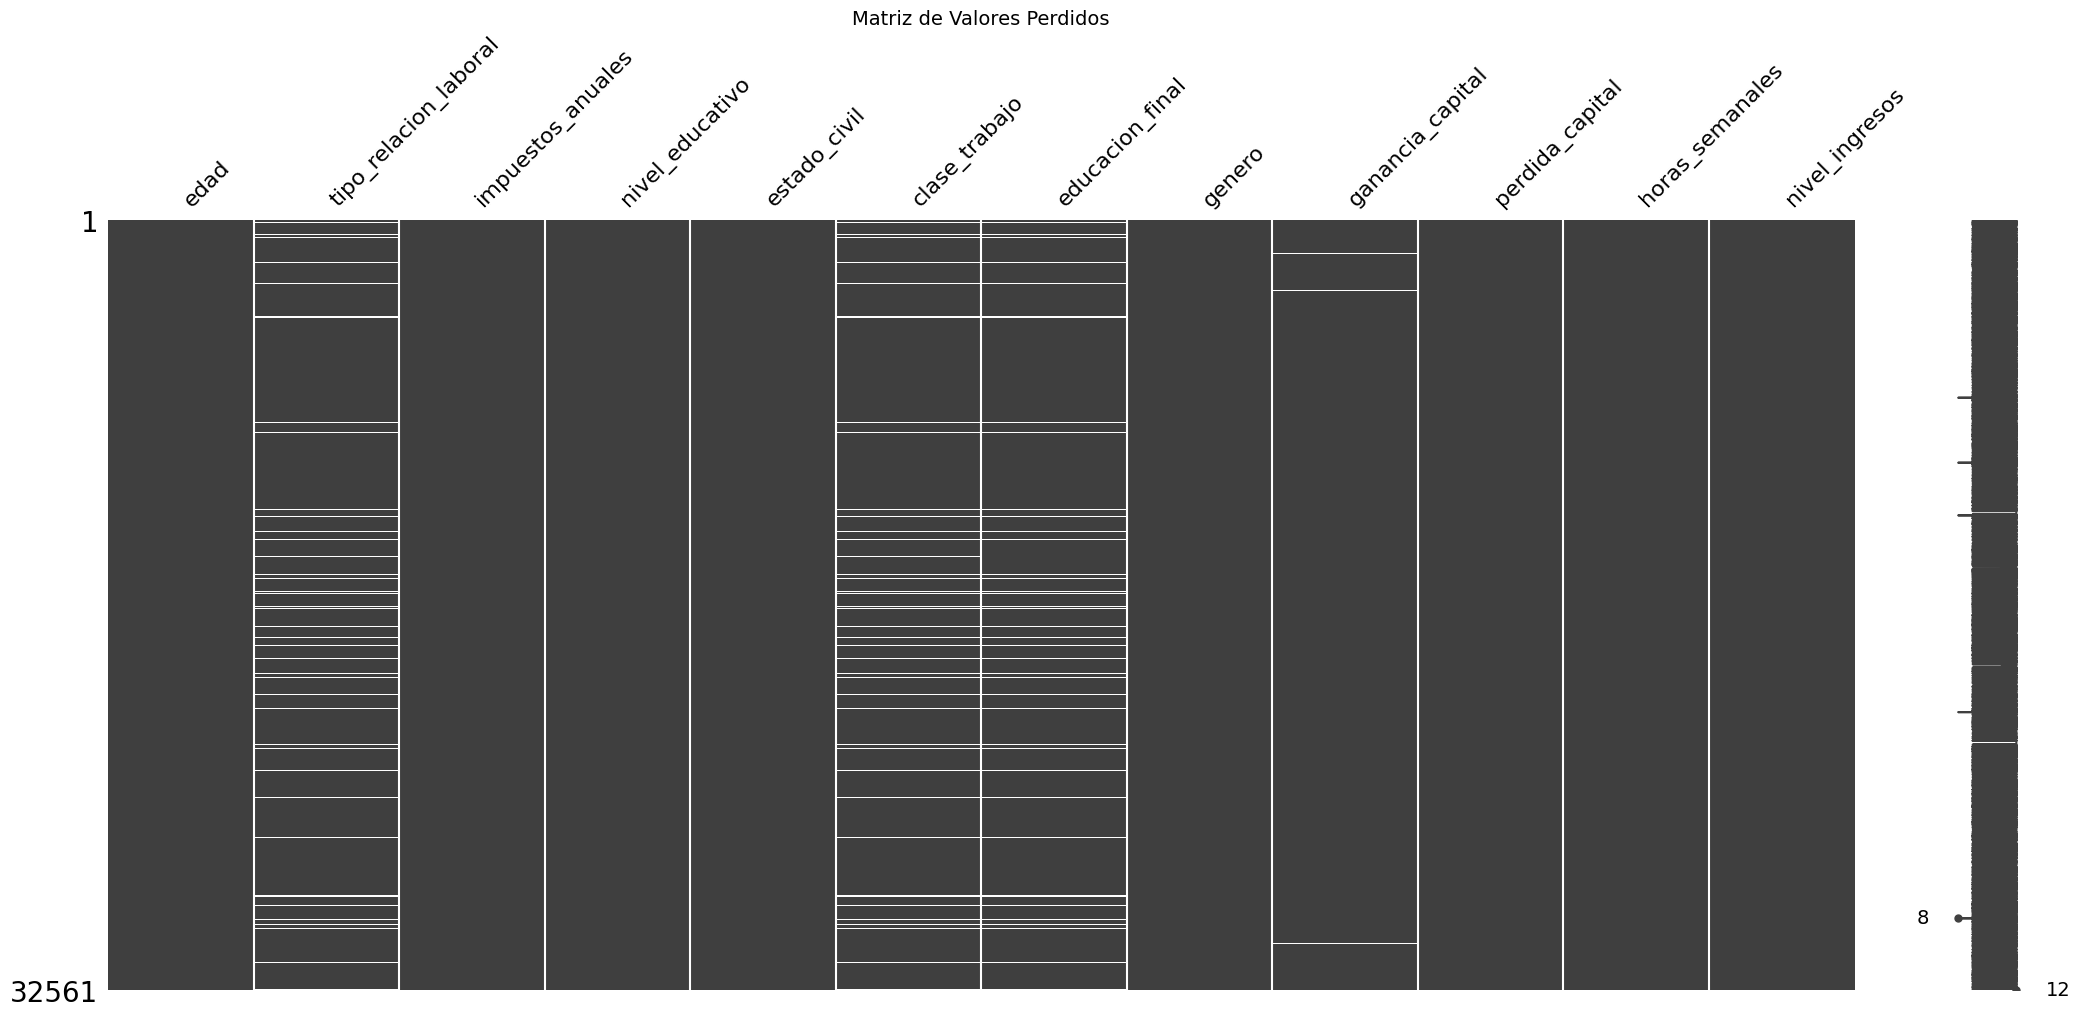

In [10]:
# Matriz de valores perdidos
plt.figure(figsize=(12, 5))
msno.matrix(censo)
plt.title('Matriz de Valores Perdidos', fontsize=14)
plt.show()

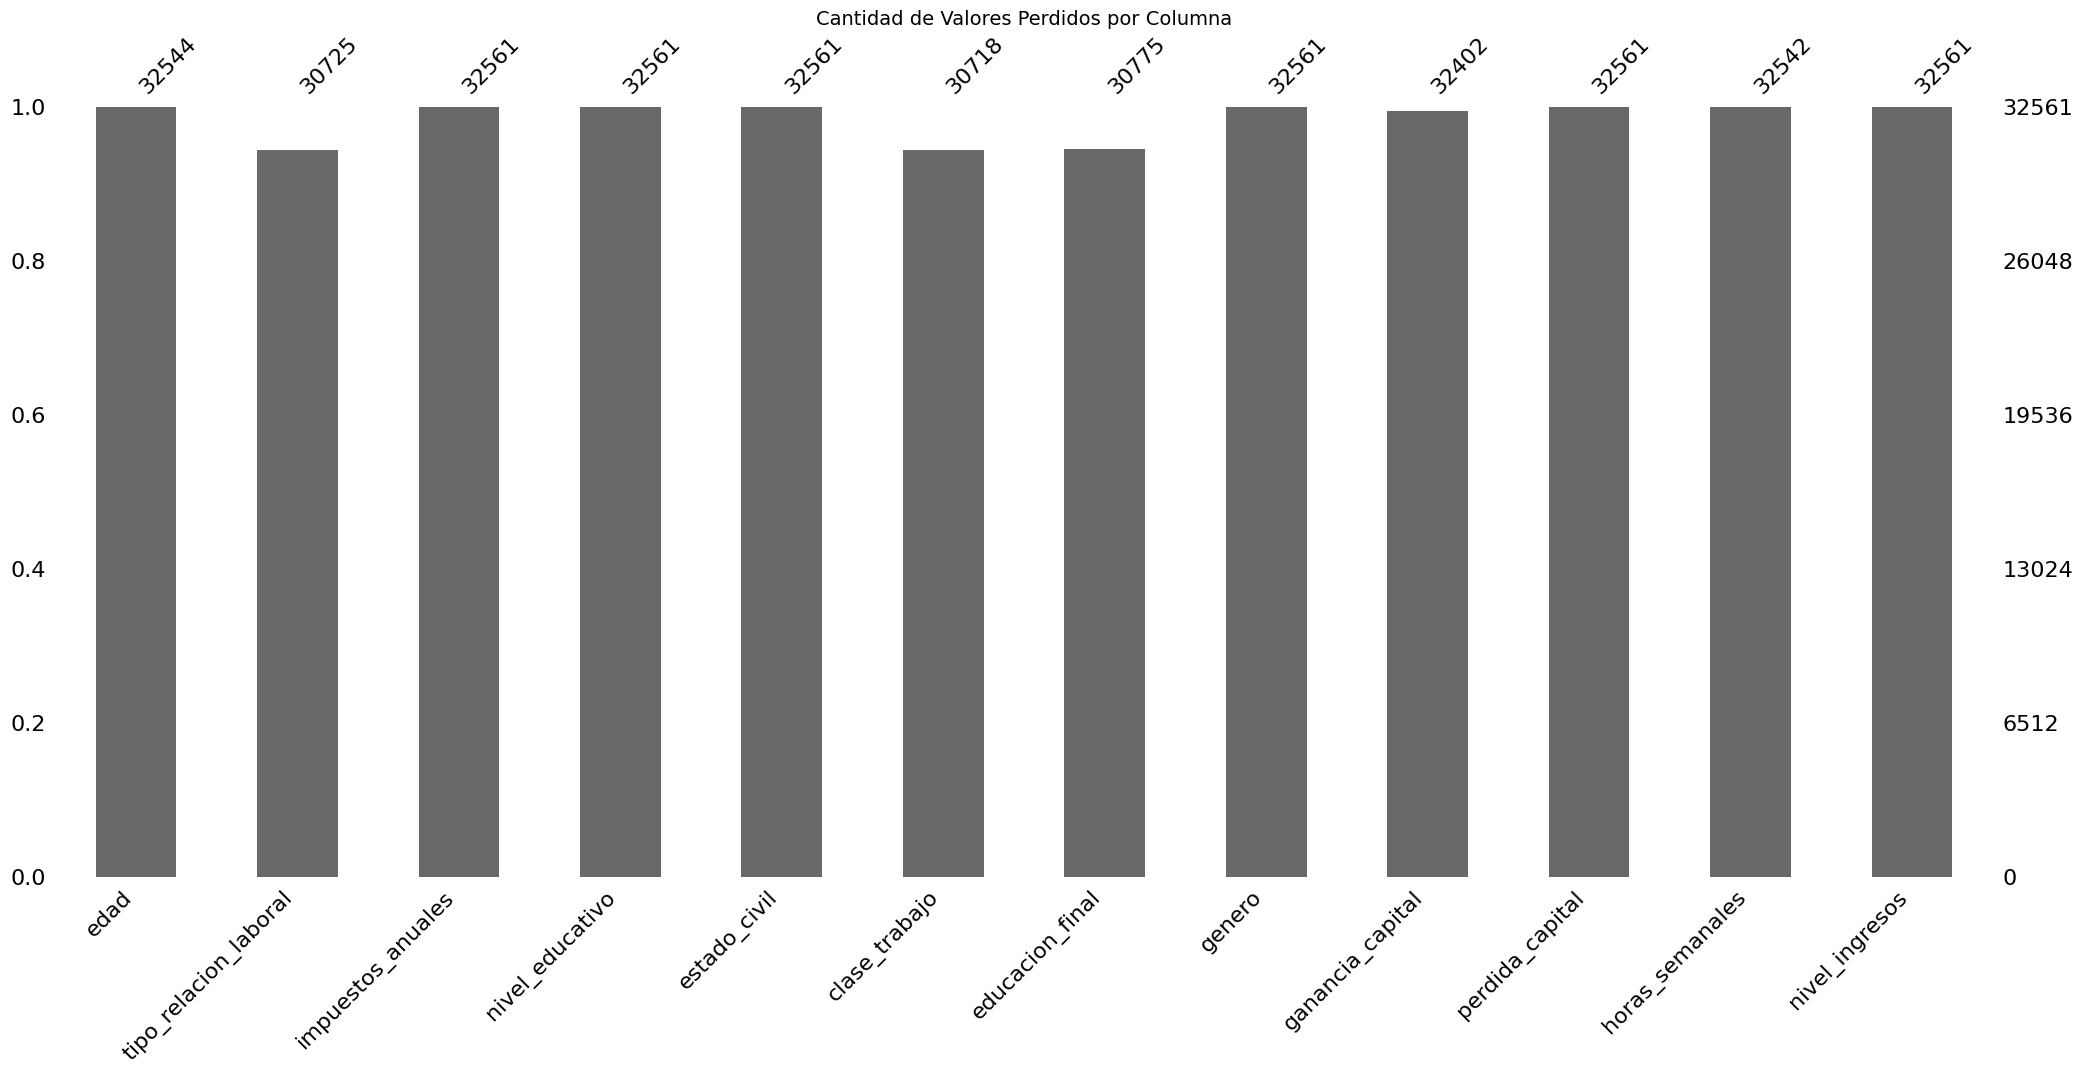

In [11]:
# Barras de valores perdidos
msno.bar(censo)
plt.title('Cantidad de Valores Perdidos por Columna', fontsize=14)
plt.show()

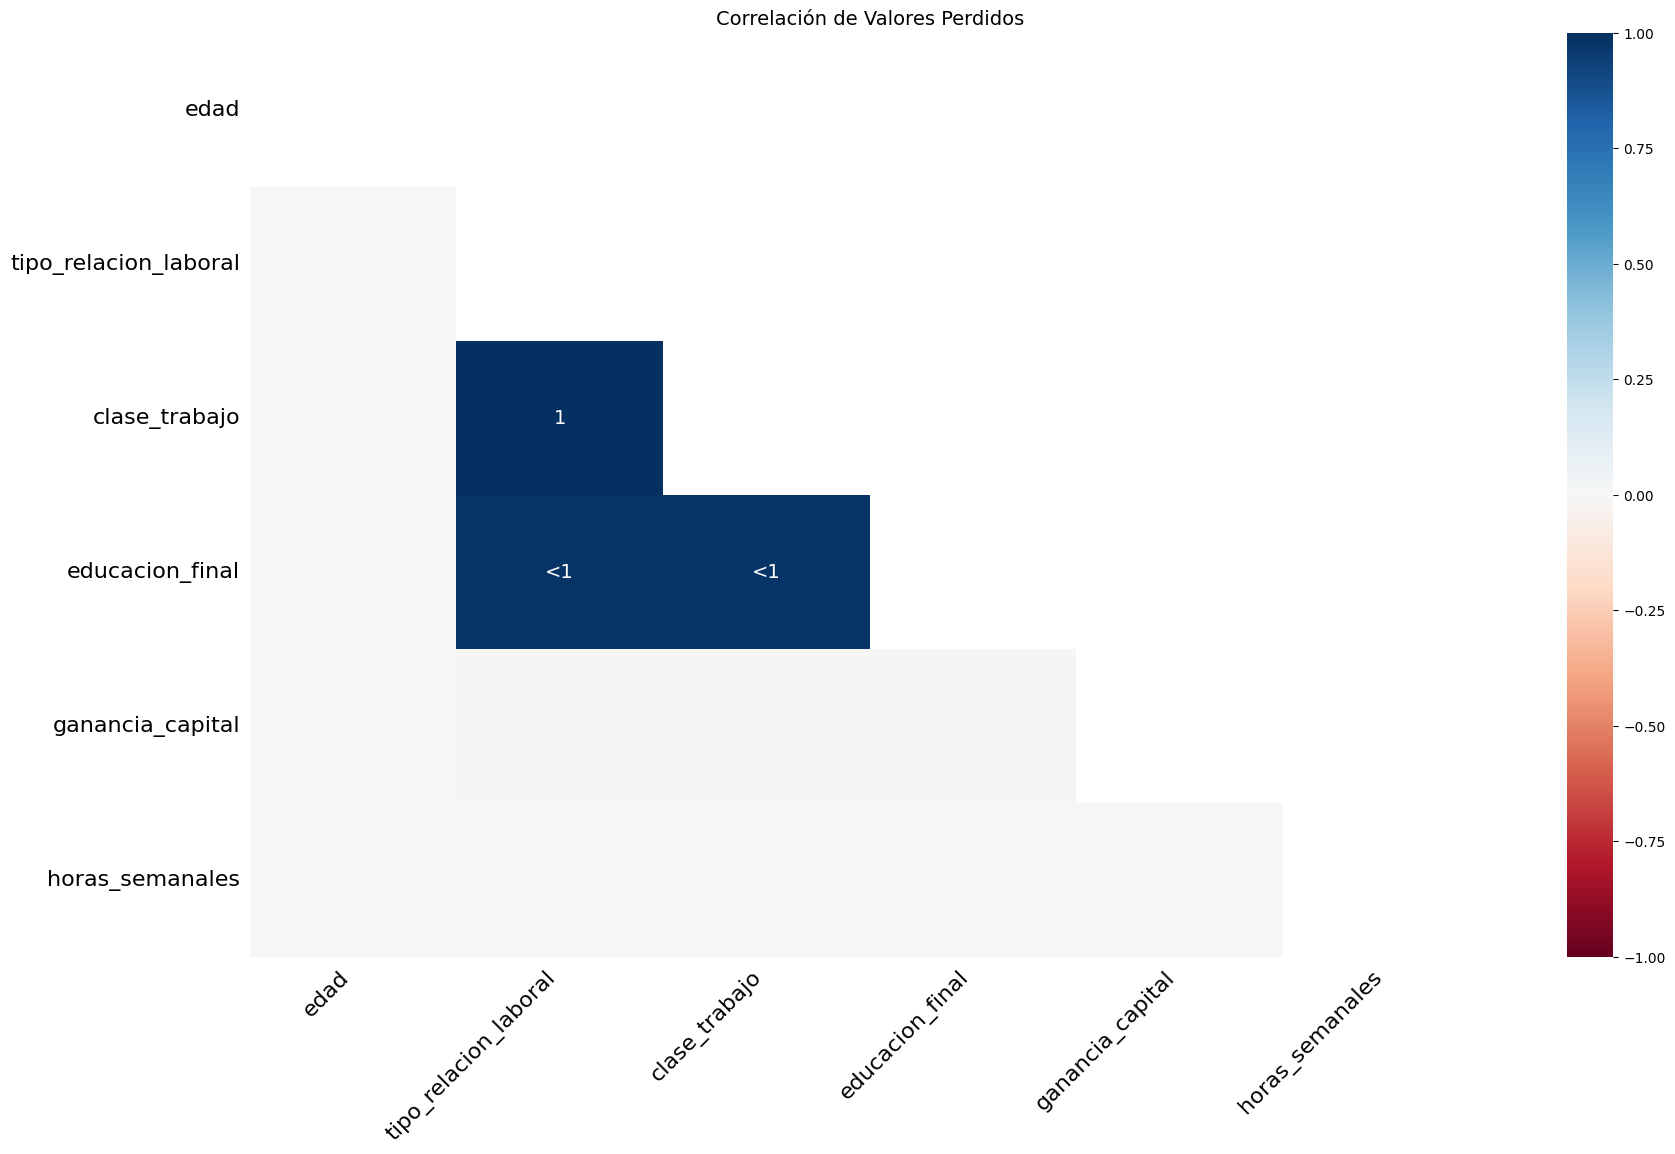

In [12]:
# Heatmap: correlación entre columnas con NA
msno.heatmap(censo)
plt.title('Correlación de Valores Perdidos', fontsize=14)
plt.show()

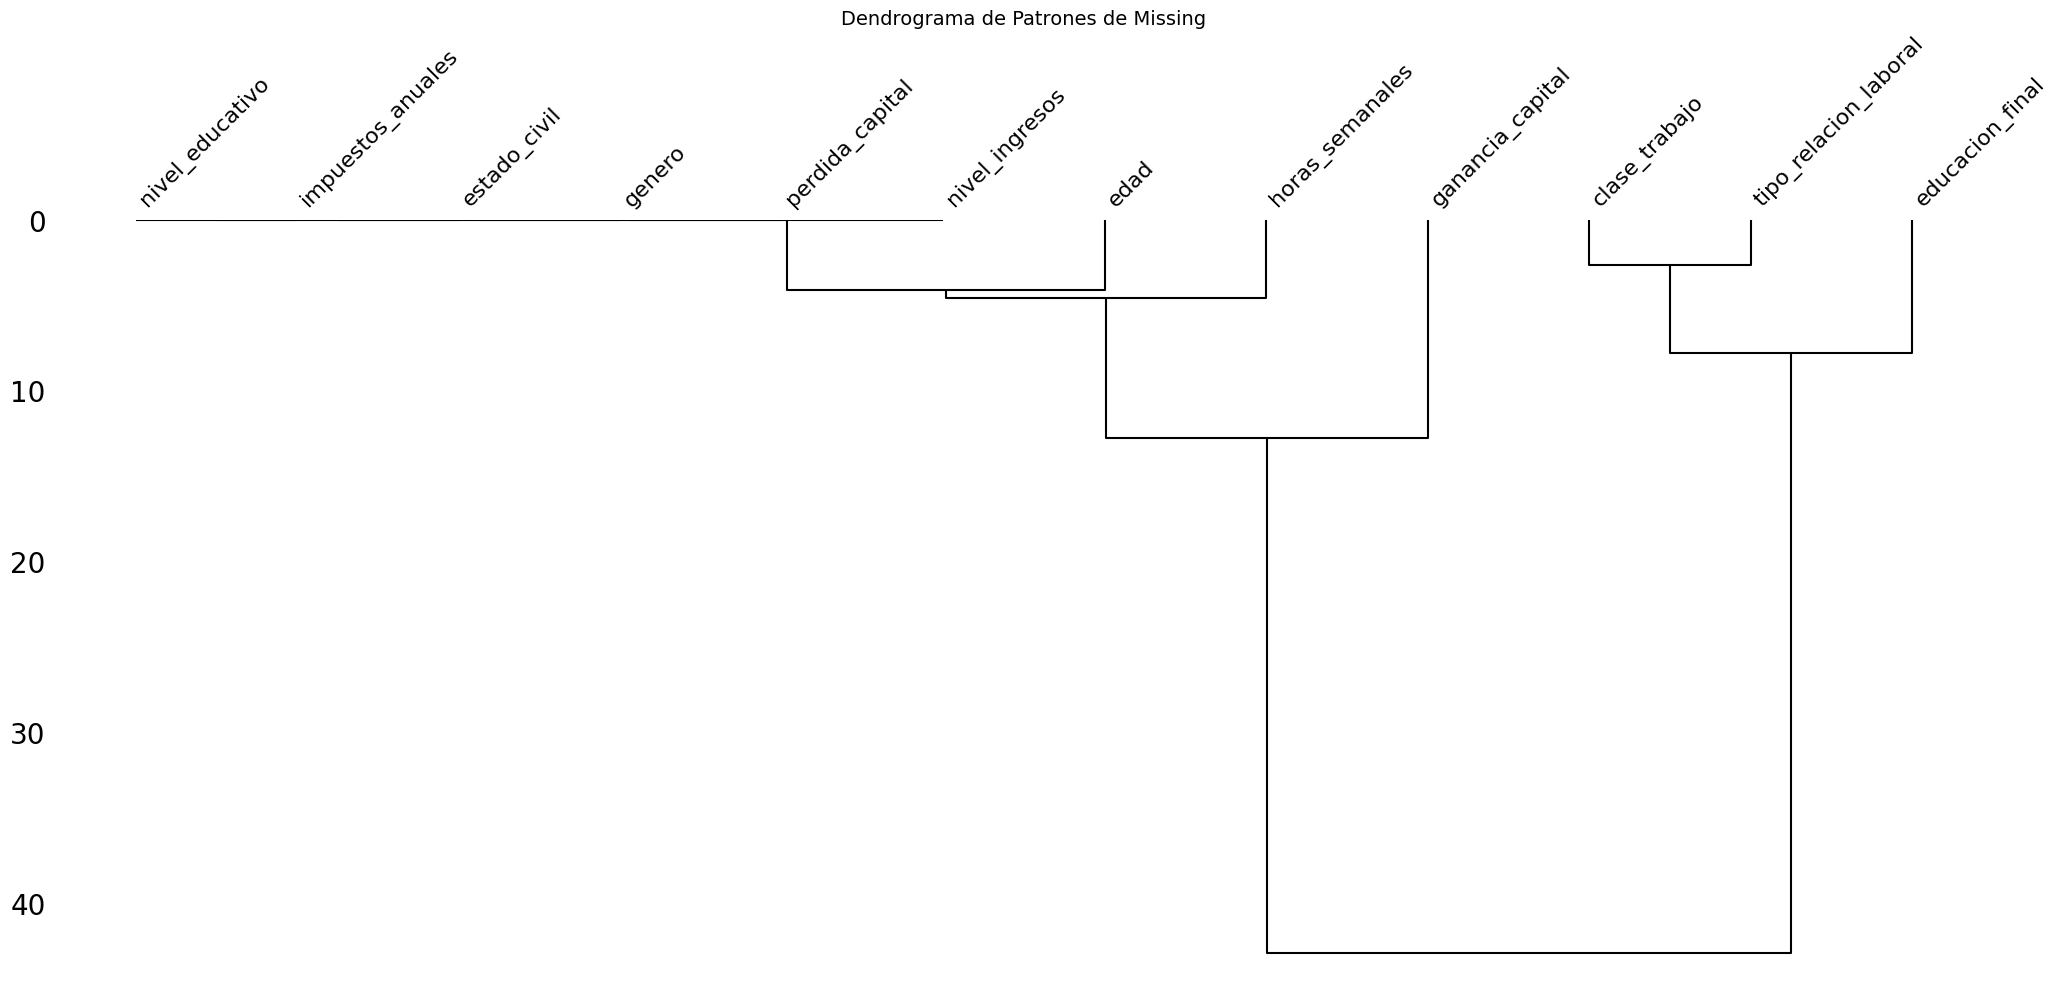

In [13]:
# Dendrograma: clustering de patrones de missing
msno.dendrogram(censo)
plt.title('Dendrograma de Patrones de Missing', fontsize=14)
plt.show()

---
## 6. Comparación de Estrategias de Imputación

Evaluamos dos estrategias para imputar valores faltantes:

### Estrategia A: Mediana (numéricas) + Moda (categóricas)
- Simple y rápida
- Mediana: robusta ante outliers (a diferencia de la media)
- Moda: el valor más frecuente para categóricas

### Estrategia B: KNN (numéricas) + Moda (categóricas)
- KNN (K-Nearest Neighbors): estima valores basándose en los k registros más similares
- Conserva relaciones entre variables
- Más costoso computacionalmente pero potencialmente más preciso

### Criterio de comparación
Para decidir cuál es mejor, compararemos las distribuciones resultantes.
Una buena imputación debe:
1. Mantener la media/mediana original (sin sesgar)
2. Preservar la variabilidad natural de los datos

In [14]:
# ===========================================================
# 6. COMPARACIÓN DE IMPUTACIONES
# ===========================================================

# Definir columnas por tipo
columnas_numericas = ['edad', 'impuestos_anuales', 'ganancia_capital',
                      'perdida_capital', 'horas_semanales']
columnas_categoricas = ['tipo_relacion_laboral', 'clase_trabajo', 'educacion_final']

In [15]:
# ===========================================================
# 6.1. ESTRATEGIA A: MEDIANA + MODA
# ===========================================================

censo_mediana = censo.copy()

# Numéricas → Mediana
censo_mediana[columnas_numericas] = SimpleImputer(
    strategy='median'
).fit_transform(censo_mediana[columnas_numericas])

# Categóricas → Moda (most_frequent)
censo_mediana[columnas_categoricas] = SimpleImputer(
    strategy='most_frequent'
).fit_transform(censo_mediana[columnas_categoricas])

na_restantes = censo_mediana.isna().sum().sum()
print(f'NA restantes (Mediana+Moda): {na_restantes}')

NA restantes (Mediana+Moda): 0


In [16]:
# ===========================================================
# 6.2. ESTRATEGIA B: KNN + MODA
# ===========================================================

censo_knn = censo.copy()

# Numéricas → KNN (k=5 vecinos)
knn_imputer = KNNImputer(n_neighbors=5)
censo_knn[columnas_numericas] = knn_imputer.fit_transform(censo_knn[columnas_numericas])

# Categóricas → Moda
censo_knn[columnas_categoricas] = SimpleImputer(
    strategy='most_frequent'
).fit_transform(censo_knn[columnas_categoricas])

na_restantes = censo_knn.isna().sum().sum()
print(f'NA restantes (KNN+Moda): {na_restantes}')

NA restantes (KNN+Moda): 0


In [17]:
# ===========================================================
# 6.3. COMPARACIÓN DE RESULTADOS
# ===========================================================

# Crear tabla comparativa de estadísticos
comparacion = pd.DataFrame({
    'Original_Media': censo[columnas_numericas].mean(),
    'Mediana_Media': censo_mediana[columnas_numericas].mean(),
    'KNN_Media': censo_knn[columnas_numericas].mean(),
    'Original_DesvStd': censo[columnas_numericas].std(),
    'Mediana_DesvStd': censo_mediana[columnas_numericas].std(),
    'KNN_DesvStd': censo_knn[columnas_numericas].std()
})

# Calcular diferencia relativa %
comparacion['Mediana_Diff(%)'] = (
    (comparacion['Mediana_Media'] - comparacion['Original_Media'])
    / comparacion['Original_Media'].abs() * 100
)
comparacion['KNN_Diff(%)'] = (
    (comparacion['KNN_Media'] - comparacion['Original_Media'])
    / comparacion['Original_Media'].abs() * 100
)

print('=== COMPARACIÓN DE ESTRATEGIAS DE IMPUTACIÓN ===')
print()
print('En una buena imputación, las medias deben cambiar lo menos posible.')
print()
comparacion.round(4)

=== COMPARACIÓN DE ESTRATEGIAS DE IMPUTACIÓN ===

En una buena imputación, las medias deben cambiar lo menos posible.



,Original_Media,Mediana_Media,KNN_Media,Original_DesvStd,Mediana_DesvStd,KNN_DesvStd,Mediana_Diff(%),KNN_Diff(%)
edad,38.5822,38.5813,38.5829,13.6411,13.6376,13.6380,-0.0021,0.0018
impuestos_anuales,189778.3665,189778.3665,189778.3665,105549.9777,105549.9777,105549.9777,0.0000,0.0000
ganancia_capital,668.4119,665.1480,669.5312,2597.5584,2591.6272,2593.3609,-0.4883,0.1674
perdida_capital,137.5265,137.5265,137.5265,688.7638,688.7638,688.7638,0.0000,0.0000
horas_semanales,40.4369,40.4367,40.4374,12.3484,12.3448,12.3453,-0.0006,0.0010


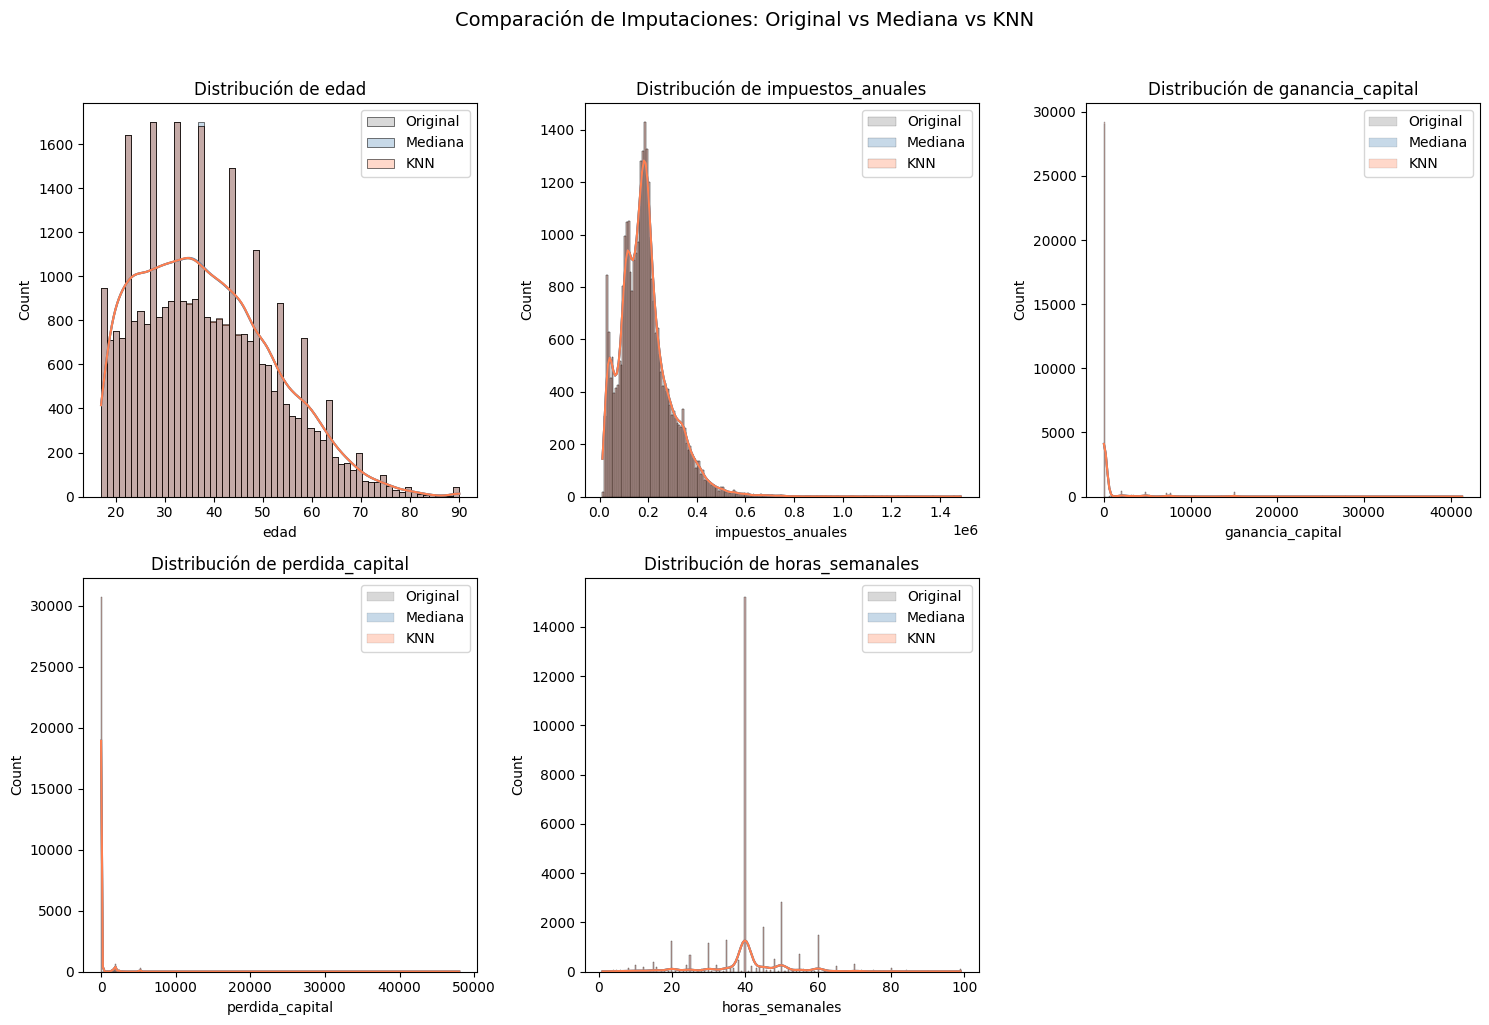

In [18]:
# Gráfico comparativo: distribución original vs imputada
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Colores para cada método
colores = {'original': 'gray', 'mediana': 'steelblue', 'knn': 'coral'}

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    # Datos originales (sin NA)
    sns.histplot(censo[col].dropna(), color=colores['original'],
                 kde=True, alpha=0.3, label='Original', ax=ax)
    # Imputación Mediana
    sns.histplot(censo_mediana[col], color=colores['mediana'],
                 kde=True, alpha=0.3, label='Mediana', ax=ax)
    # Imputación KNN
    sns.histplot(censo_knn[col], color=colores['knn'],
                 kde=True, alpha=0.3, label='KNN', ax=ax)
    ax.set_title(f'Distribución de {col}')
    ax.legend()

for ax in axes[len(columnas_numericas):]:
    ax.set_visible(False)

plt.suptitle('Comparación de Imputaciones: Original vs Mediana vs KNN',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ===========================================================
# 6.4. ELECCIÓN DEL MEJOR MÉTODO
# ===========================================================

# Calcular diferencia absoluta promedio para cada método
diff_mediana = comparacion['Mediana_Diff(%)'].abs().mean()
diff_knn = comparacion['KNN_Diff(%)'].abs().mean()

print(f'Diferencia porcentual promedio (Mediana): {diff_mediana:.4f}%')
print(f'Diferencia porcentual promedio (KNN): {diff_knn:.4f}%')
print()

if diff_knn <= diff_mediana:
    print('✓ KNN se comporta igual o mejor que Mediana. Elegimos KNN.')
    censo_imputado = censo_knn.copy()
else:
    print('✓ Mediana se comporta mejor. Elegimos Mediana.')
    censo_imputado = censo_mediana.copy()

print()
print(f'Dataset final dimensiones: {censo_imputado.shape}')

Diferencia porcentual promedio (Mediana): 0.0982%
Diferencia porcentual promedio (KNN): 0.0341%

✓ KNN se comporta igual o mejor que Mediana. Elegimos KNN.

Dataset final dimensiones: (32561, 12)


---
## 7. Detección y Eliminación de Duplicados

Los registros duplicados no aportan información nueva y pueden sesgar el análisis. Identificamos y eliminamos filas exactamente iguales.

In [20]:
# ===========================================================
# 7. DUPLICADOS
# ===========================================================

n_original = len(censo_imputado)

# Identificar duplicados
duplicados = censo_imputado[censo_imputado.duplicated()]
print(f'Filas duplicadas (manteniendo primera): {len(duplicados)}')

# Eliminar duplicados
censo_imputado = censo_imputado.drop_duplicates()
n_final = len(censo_imputado)

print(f'Registros eliminados por duplicación: {n_original - n_final}')
print(f'Dataset final: {n_final} filas, {censo_imputado.shape[1]} columnas')

Filas duplicadas (manteniendo primera): 73
Registros eliminados por duplicación: 73
Dataset final: 32488 filas, 12 columnas


---
## 8. Visualización de Datos

Exploramos visualmente las variables del dataset limpio:

- **8.1. Histogramas**: distribuciones de variables numéricas
- **8.2. Boxplots**: detección de outliers e IQR
- **8.3. Heatmap de correlaciones**: relaciones lineales entre numéricas
- **8.4. Barras**: frecuencias de variables categóricas

In [21]:
# ===========================================================
# 8. VISUALIZACIÓN
# ===========================================================

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

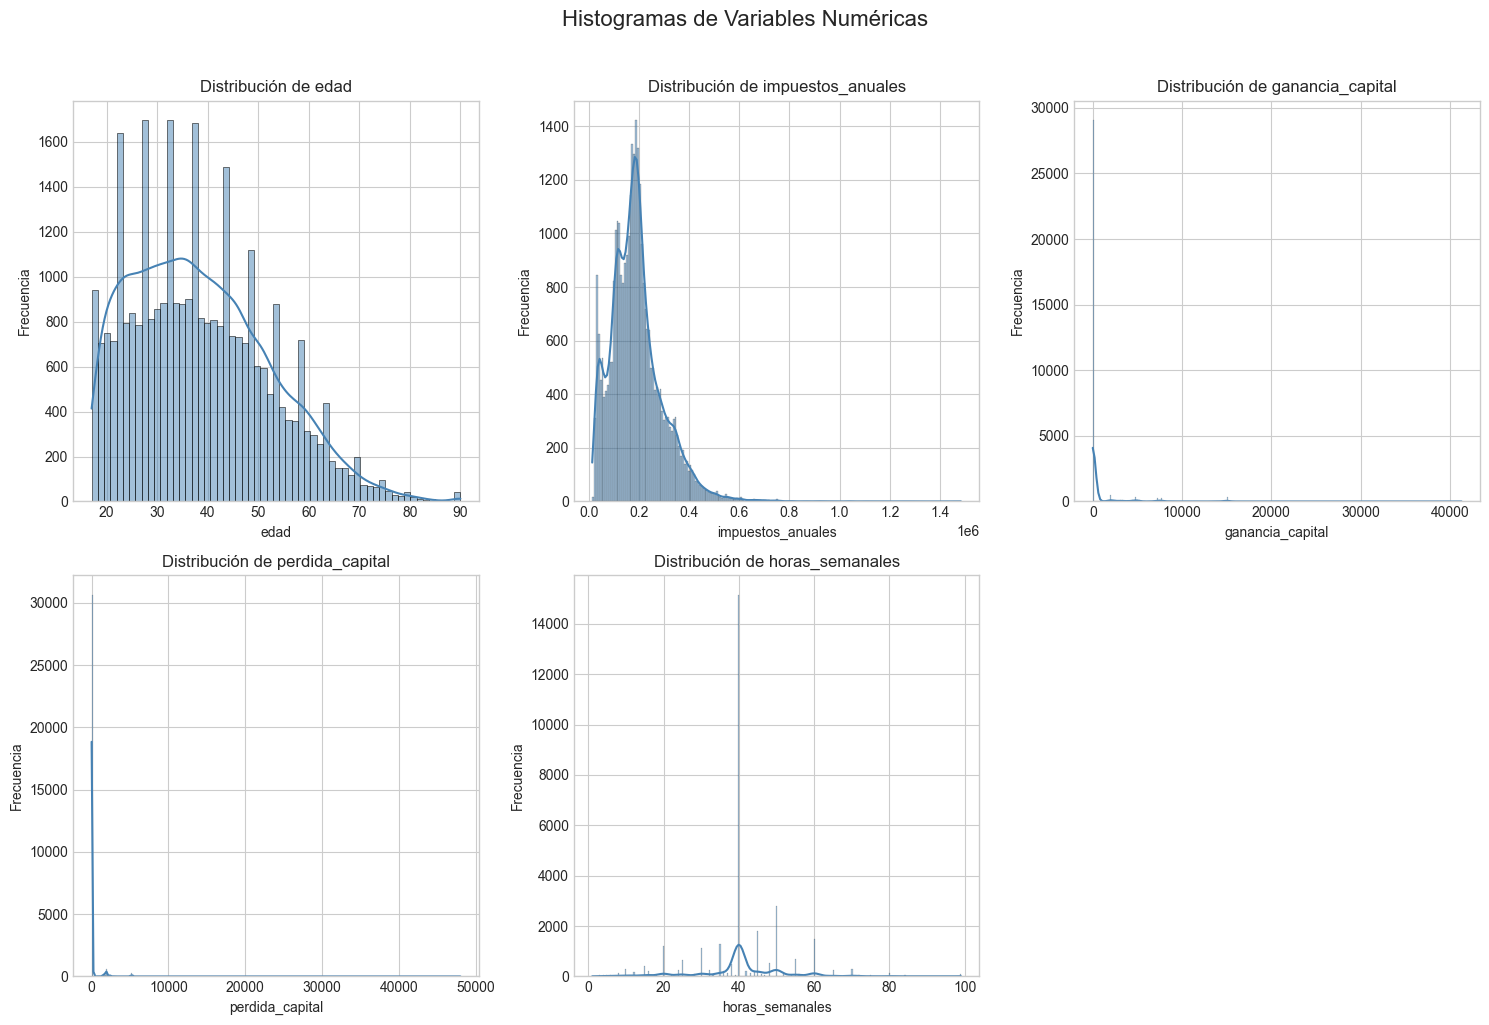

In [22]:
# 8.1. Histogramas de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.histplot(censo_imputado[col], kde=True, color='steelblue', ax=axes[i])
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

for ax in axes[len(columnas_numericas):]:
    ax.set_visible(False)

plt.suptitle('Histogramas de Variables Numéricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

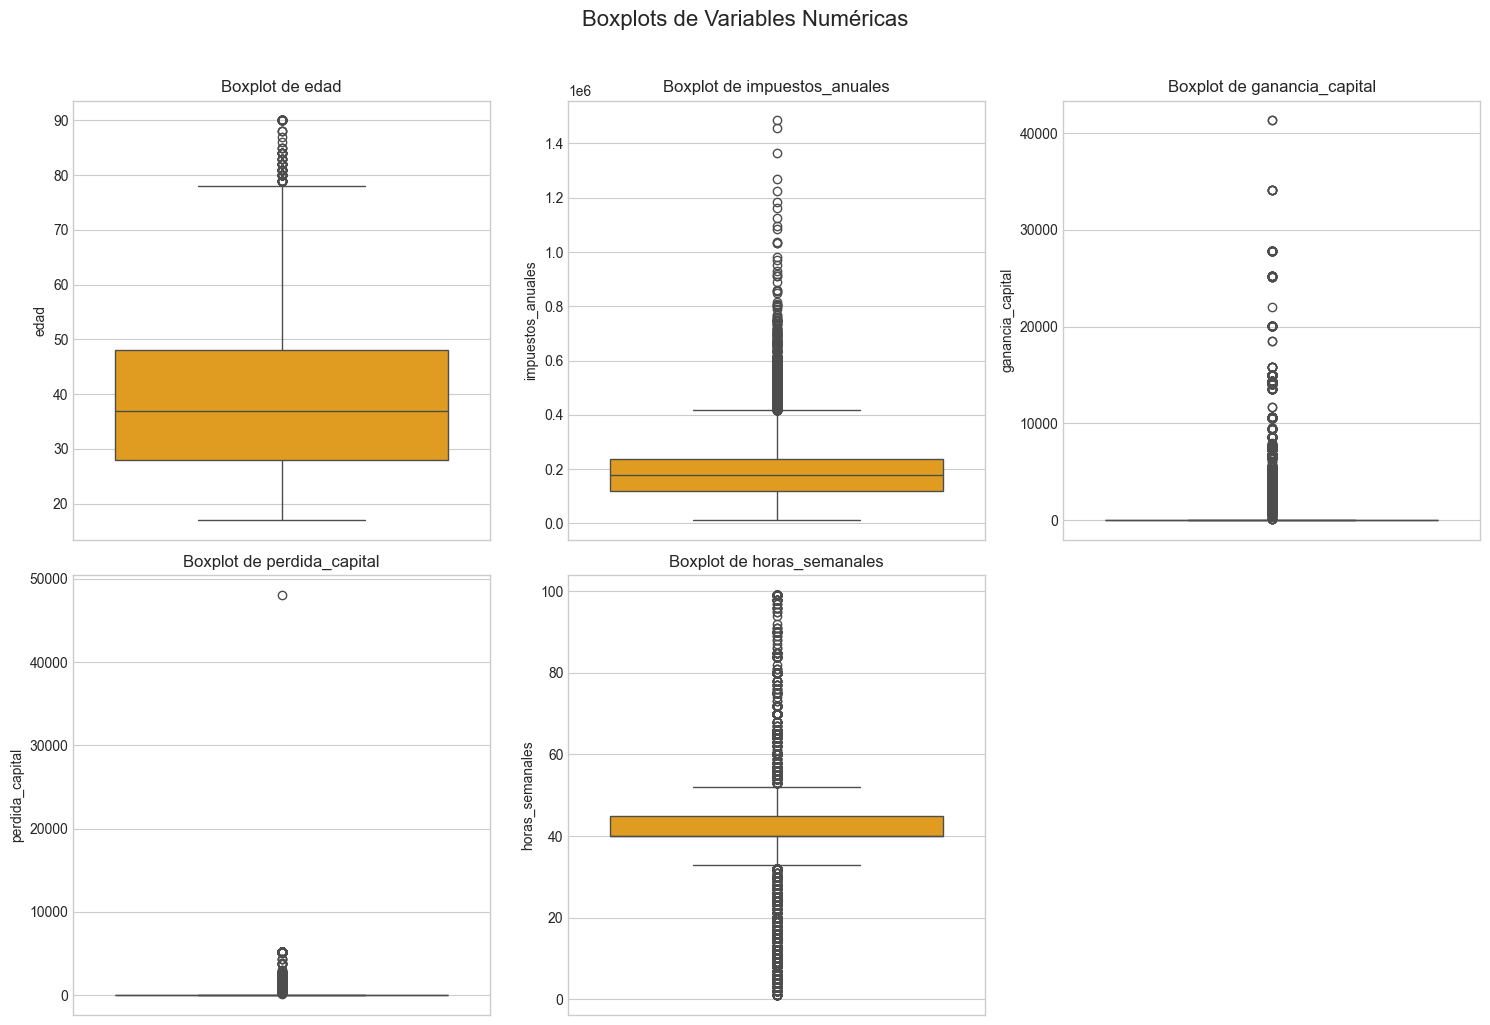

In [23]:
# 8.2. Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=censo_imputado[col], color='orange', ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_ylabel(col)

for ax in axes[len(columnas_numericas):]:
    ax.set_visible(False)

plt.suptitle('Boxplots de Variables Numéricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

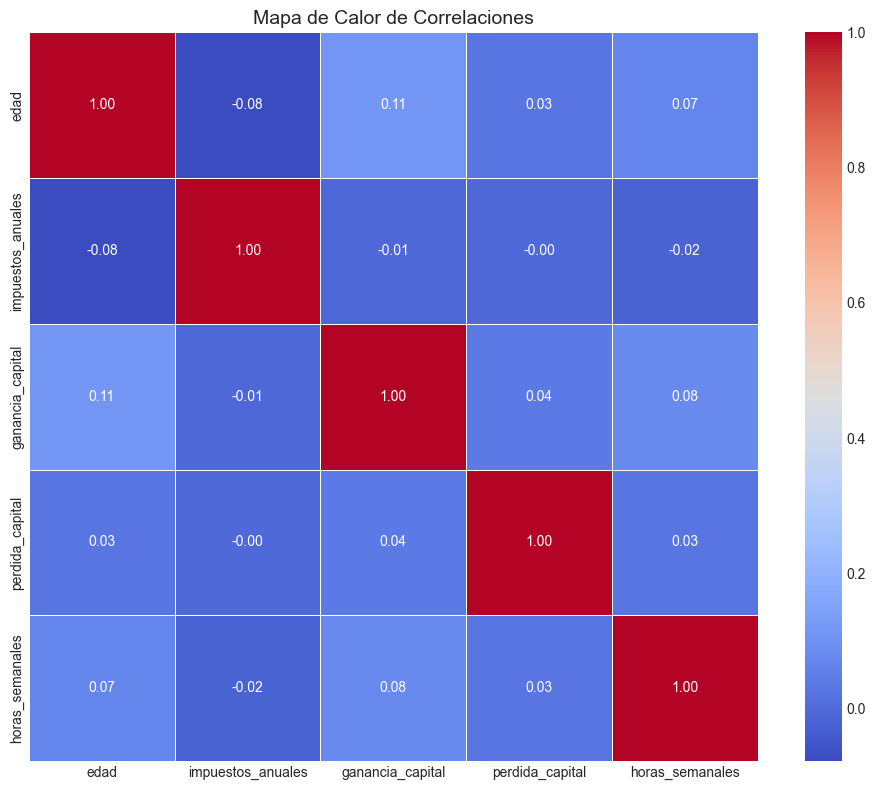

In [24]:
# 8.3. Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
correlacion = censo_imputado[columnas_numericas].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Mapa de Calor de Correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

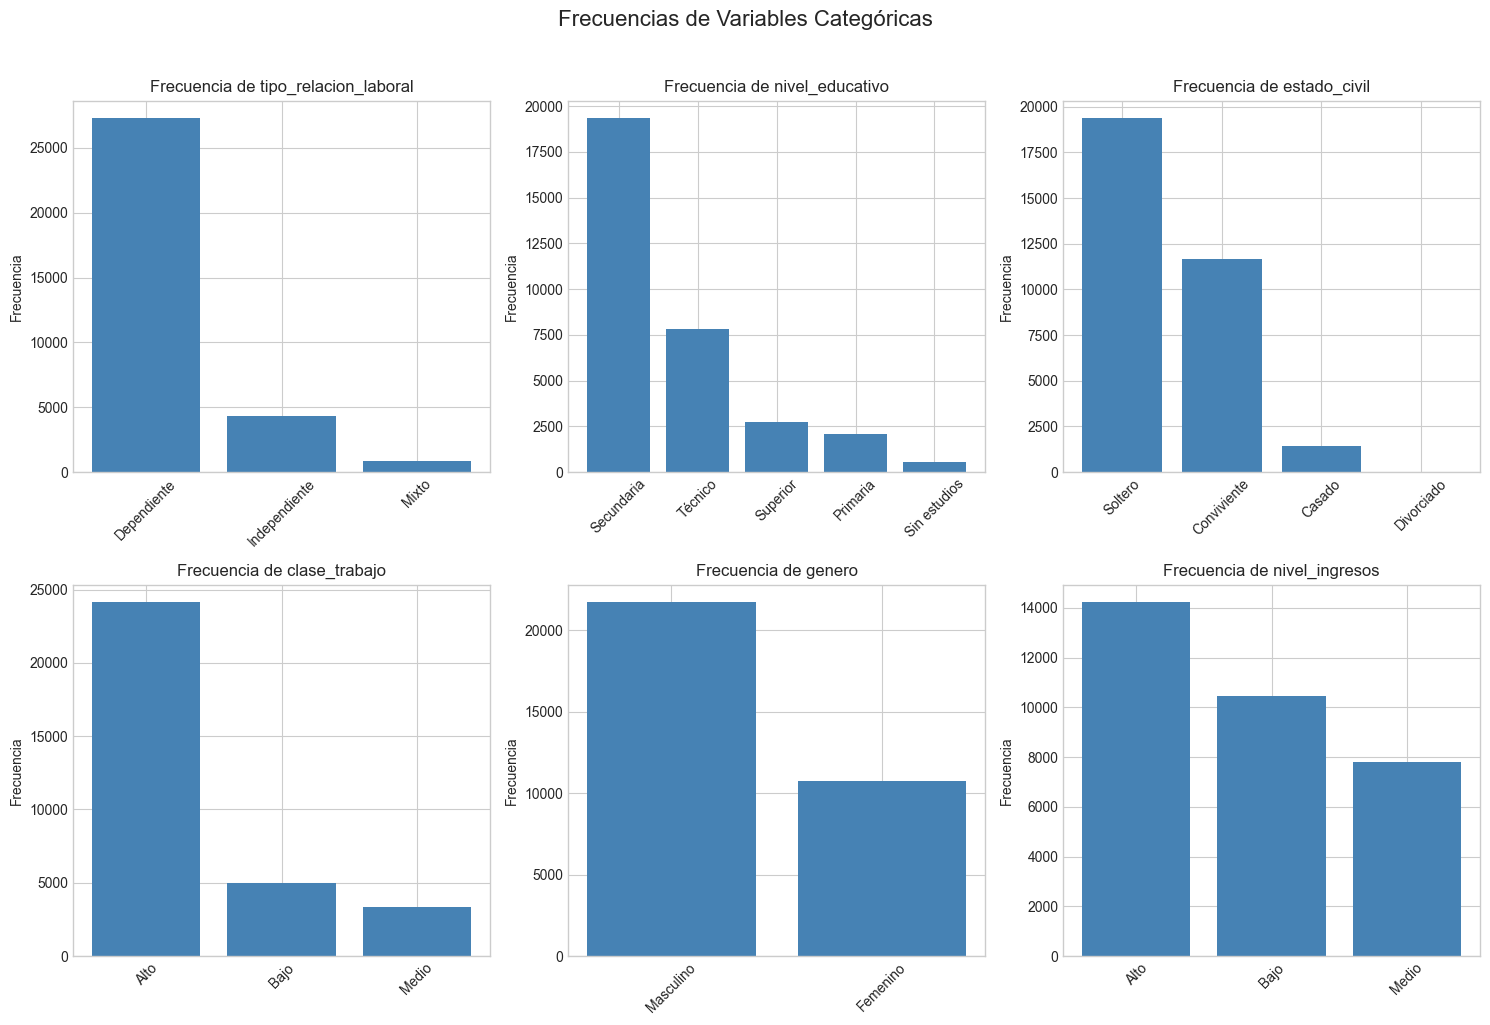

In [25]:
# 8.4. Frecuencias de variables categóricas
variables_categoricas = ['tipo_relacion_laboral', 'nivel_educativo',
                         'estado_civil', 'clase_trabajo', 'genero', 'nivel_ingresos']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    conteo = censo_imputado[col].value_counts()
    axes[i].bar(conteo.index, conteo.values, color='steelblue')
    axes[i].set_title(f'Frecuencia de {col}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Frecuencia')

for ax in axes[len(variables_categoricas):]:
    ax.set_visible(False)

plt.suptitle('Frecuencias de Variables Categóricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Exportación del Dataset Limpio

Guardamos el dataset limpio en un archivo CSV para usarlo en la etapa de modelado.

In [26]:
# ===========================================================
# 9. EXPORTACIÓN
# ===========================================================

ruta_salida = 'Census_limpio.csv'
censo_imputado.to_csv(ruta_salida, index=False, encoding='utf-8')

print(f'Dataset limpio exportado a: {ruta_salida}')
print(f'Formato: {censo_imputado.shape[0]} filas x {censo_imputado.shape[1]} columnas')
print()
print('Resumen final del dataset:')
censo_imputado.info()

Dataset limpio exportado a: Census_limpio.csv
Formato: 32488 filas x 12 columnas

Resumen final del dataset:
<class 'pandas.DataFrame'>
Index: 32488 entries, 0 to 32560
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   edad                   32488 non-null  float64
 1   tipo_relacion_laboral  32488 non-null  str    
 2   impuestos_anuales      32488 non-null  float64
 3   nivel_educativo        32488 non-null  str    
 4   estado_civil           32488 non-null  str    
 5   clase_trabajo          32488 non-null  str    
 6   educacion_final        32488 non-null  str    
 7   genero                 32488 non-null  str    
 8   ganancia_capital       32488 non-null  float64
 9   perdida_capital        32488 non-null  float64
 10  horas_semanales        32488 non-null  float64
 11  nivel_ingresos         32488 non-null  str    
dtypes: float64(5), str(7)
memory usage: 4.8 MB
